Model loaded successfully!
Searching for available image files...
Found image at: C:\Users\ashan\Downloads\dog.jpg


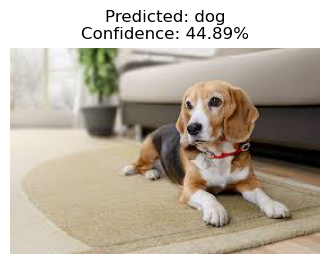

Predicted class for the single image: dog with confidence 44.89%

Processing images from folder: D:\MY-project\CNN\TestImage


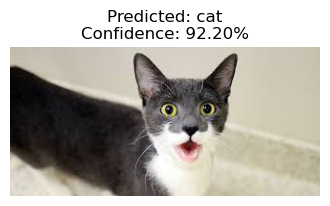

cat1.jpg: cat (Confidence: 92.20%)


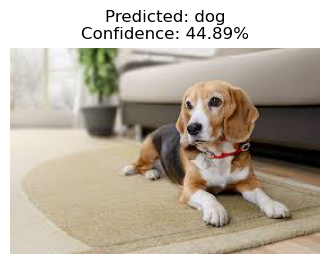

dog.jpg: dog (Confidence: 44.89%)


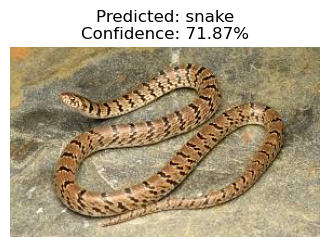

snake.jpg: snake (Confidence: 71.87%)


In [1]:
import torch
from torchvision import transforms
from PIL import Image
import os
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F

# Define your model class (should be the same as training)
class AnimalCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.Dropout2d(0.2),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.Dropout2d(0.3),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self._to_linear = None
        self._get_flattened_size()
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self._to_linear, 256), nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
    
    def _get_flattened_size(self):
        with torch.no_grad():
            x = torch.zeros(1, 3, 128, 128)
            x = self.features(x)
            self._to_linear = x.view(1, -1).shape[1]
    
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Replace with your actual class names in order
class_names = ['cat', 'dog', 'snake']

# Load the saved model and set it to evaluation mode
num_classes = len(class_names)
model = AnimalCNN(num_classes)

# Check if model file exists before loading
model_path = r'D:\MY-project\CNN\AnimalDetection_CNN.pth'
if not os.path.exists(model_path):
    print(f"Error: Model file not found at {model_path}")
    print("Please check the model file path.")
else:
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()
    print("Model loaded successfully!")

# Image preprocessing (same as training)
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], 
                         [0.229, 0.224, 0.225])
])

def predict_image(image_path):
    # Check if image file exists
    if not os.path.exists(image_path):
        print(f"Error: Image file not found at {image_path}")
        return None, None
    
    try:
        image = Image.open(image_path).convert('RGB')
        input_tensor = transform(image).unsqueeze(0).to(device)  # Add batch dimension and move to device
        
        with torch.no_grad():
            outputs = model(input_tensor)
            probabilities = F.softmax(outputs, dim=1)  # Get probabilities with softmax
            confidence, predicted = torch.max(probabilities, 1)
            confidence = confidence.item()
            class_idx = predicted.item()
        
        # Visualize the image
        plt.figure(figsize=(4,4))
        plt.imshow(image)
        plt.title(f"Predicted: {class_names[class_idx]}\nConfidence: {confidence*100:.2f}%")
        plt.axis('off')
        plt.show()
        
        return class_names[class_idx], confidence
    
    except Exception as e:
        print(f"Error processing image {image_path}: {str(e)}")
        return None, None

# Method 1: Check if the specific image exists and provide alternatives
def find_image_file():
    """Find available image files in common locations"""
    possible_paths = [
        r'C:\Users\ashan\Downloads\dog1.jpg',
        r'C:\Users\ashan\Downloads\dog.jpg',
        r'C:\Users\ashan\Pictures\dog1.jpg',
        r'.\dog1.jpg',  # Current directory
        r'.\test_images\dog1.jpg'
    ]
    
    # Check Downloads folder for any dog images
    downloads_folder = r'C:\Users\ashan\Downloads'
    if os.path.exists(downloads_folder):
        for file in os.listdir(downloads_folder):
            if 'dog' in file.lower() and file.lower().endswith(('.png', '.jpg', '.jpeg')):
                return os.path.join(downloads_folder, file)
    
    # Check the predefined paths
    for path in possible_paths:
        if os.path.exists(path):
            return path
    
    return None

# Try to find an available image file
print("Searching for available image files...")
image_path = find_image_file()

if image_path:
    print(f"Found image at: {image_path}")
    predicted_class, confidence = predict_image(image_path)
    if predicted_class:
        print(f"Predicted class for the single image: {predicted_class} with confidence {confidence*100:.2f}%")
else:
    print("No suitable image file found. Please check the following:")
    print("1. Make sure 'dog1.jpg' exists in C:\\Users\\ashan\\Downloads\\")
    print("2. Or place an image file in the current directory")
    print("3. Or update the image_path variable with the correct path")

# For multiple images
image_folder = r'D:\MY-project\CNN\TestImage'

if os.path.exists(image_folder):
    print(f"\nProcessing images from folder: {image_folder}")
    image_files = [f for f in os.listdir(image_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
    if image_files:
        for img_file in image_files:
            img_path = os.path.join(image_folder, img_file)
            pred_class, conf = predict_image(img_path)
            if pred_class:
                print(f"{img_file}: {pred_class} (Confidence: {conf*100:.2f}%)")
    else:
        print("No image files found in the test folder.")
else:
    print(f"Test image folder not found: {image_folder}")
    print("Please create the folder and add test images, or update the path.")